# **社群媒體分析期末專案：**

**課程：** 社群媒體分析  
**教授：** 黃三益 老師  
**組別：** 第三組  
**組員：** 林佩蓉 N124320015、林㛄婷 N134020008、林曉君 N134320024、黃瀞儀 N134320032

---

## 法人交易資訊下的 PTT 討論熱點轉移——留言清理

本檔案為留言資料的處理

本研究原始資料來源為PTT Stock版，以`上市買賣超`為關鍵字，以TarFlow爬取 `2026/01/01 ~ 2026/06/01` 間的貼文，取得
- \[情報\]{日期}上市投信買賣超排行
- \[情報\]{日期}上市外資買賣超排行

將原始檔案中貼文部分與推文分離後進行後續處理


In [ ]:
# 環境測試
import sys
import torch

print("目前 Jupyter 使用的 Python 路徑:", sys.executable)
print("目前 PyTorch 的安裝路徑:", torch.__file__)
print("目前 PyTorch 版本:", torch.__version__)
print(torch.cuda.is_available())

目前 Jupyter 使用的 Python 路徑: D:\git\python_homework\.venv\Scripts\python.exe
目前 PyTorch 的安裝路徑: D:\git\python_homework\.venv\Lib\site-packages\torch\__init__.py
目前 PyTorch 版本: 2.9.0+cu130
True


## 0. 載入套件與參數

- 功能：載入文本處理、中文斷詞、向量化、機器學習、視覺化所需套件（如 CKIPTagger、pandas、sklearn、wordcloud）。
- 目的：建立完整 NLP 分類管線的依賴環境。
- 模型族群以傳統機器學習（TF-IDF + 線性/樹模型/貝氏）為主，不是深度學習語言模型。

In [ ]:
from ckiptagger import construct_dictionary, WS, POS, NER
import pandas as pd
import matplotlib.pyplot as plt 
import csv
from pathlib import Path
import re
import json
import time
from wordcloud import WordCloud
from collections import Counter

PROJECT_DIR = Path(__file__).resolve().parent
DATA_DIR = PROJECT_DIR / "data"

## 1. 分離貼文與推文資料

將從TarFlow上抓取下來的原始csv檔`stock_net_buy_sell_raw.csv`，分離貼文與推文部分。
各自輸出成：
- 貼文：`net_buy_sell_posts.csv`
- 推文：`net_buy_sell_comments.csv`

因PTT的推文有長度限制，超過長度後會以多則推文方式呈現。為避免這種情況造成語句的破碎，將同一篇文中的同一人的推文合併。輸出`net_buy_sell_merged_comments.csv`

此種處理方式在推文間有對話關係時，可能會遺失上下文對話關係，但本研究主要取得推文中提到的股票相關名稱，故以合併推文方式處理。

In [ ]:
ORIGINAL_FILE = DATA_DIR / "stock_net_buy_sell_raw.csv"
POSTS_FILE = DATA_DIR / "net_buy_sell_posts.csv"
COMMENTS_FILE = DATA_DIR / "net_buy_sell_comments.csv"

COMMENT_MERGED_FILE = DATA_DIR / "net_buy_sell_merged_comments.csv"

NOON = time(12, 0, 0)


# 1. 讀取原始 CSV 檔案
# 注意：若檔案很大，建議先用 nrows 測試前 100 筆
df_raw = pd.read_csv(ORIGINAL_FILE, encoding='utf-8-sig')

# 2. 定義解析 JSON 的函式
def parse_art_comment(comment_str):
    try:
        # 處理 PTT 資料中常見的雙引號重複問題，並轉為 Python 物件
        clean_str = comment_str.replace('""', '"')
        return json.loads(clean_str)
    except Exception as e:
        # 若解析失敗（例如空值），回傳空清單
        return []

# 2. 定義擷取文章分類的函數
def extract_subtitle(title):
    if not isinstance(title, str):
        return ''
    title = title.strip()
    if title.startswith('Re:'):
        return 'Re:'
    match = re.match(r'^(\[.*?\])', title)
    if match:
        return match.group(1)
    return ''

df_raw['subTitle'] = df_raw['artTitle'].apply(extract_subtitle)
# 3. 解析留言欄位
df_raw['artComment'] = df_raw['artComment'].apply(parse_art_comment)

# 新增'transDate'欄位，使用artDate的日期部分，格式為YYYY-MM-DD
df_raw['transDate'] = pd.to_datetime(df_raw['artDate'], errors='coerce').dt.date.astype(str)

# 4. 使用 explode 將「文章對應多個留言物件」展開成「一列一個留言物件」
# 此時每一列都會保留原本文章的 system_id
df_exploded = df_raw[['system_id', 'subTitle', 'artTitle', 'artCatagory', 'artComment', 'transDate']].explode('artComment')

# 5. 移除沒有留言的文章列（若原本就沒留言，artComment 會是 NaN 或空）
df_exploded = df_exploded.dropna(subset=['artComment'])

# 6. 將留言物件（Dict）扁平化為獨立欄位
# 使用 json_normalize 可以快速將字典屬性轉為欄位
comments_data = pd.json_normalize(df_exploded['artComment'])

# 7. 重新對齊索引並合併 system_id
# 因為 explode 後索引會重複，我們重設索引以利合併
df_exploded = df_exploded.reset_index(drop=True)
comments_data = comments_data.reset_index(drop=True)

df_final_comments = pd.concat([df_exploded[['system_id', 'artCatagory','subTitle', 'artTitle', 'transDate']], comments_data], axis=1)

# 移除 cmtContent 欄位最開頭的冒號
# ^: 代表只匹配字串開頭的冒號
df_final_comments['cmtContent'] = df_final_comments['cmtContent'].str.replace('^:', '', regex=True)

# 或者是使用 lstrip，它會移除左側所有指定的字元
# df_final_comments['cmtContent'] = df_final_comments['cmtContent'].str.lstrip(':')

# 8. 新增 cmtId 作為流水號（從 1 開始）
# 這能確保即使 cmtDate 相同，我們也能知道原始的先後順序
df_final_comments.insert(0, 'cmtId', range(1, len(df_final_comments) + 1))

# 9. 儲存為新的留言 CSV 檔案
df_final_comments.to_csv(COMMENTS_FILE, index=False, encoding='utf-8-sig')

print(f"處理完成！共產生 {len(df_final_comments)} 筆留言資料。")

df_posts_main = df_raw.drop(columns=['artComment'])
# 接著輸出成新檔案
df_posts_main.to_csv(POSTS_FILE, index=False, encoding='utf-8-sig')
print("主貼文資料已儲存，artComment 欄位已移除。")

### 合併留言
#df_final_comments = pd.read_csv('data/981a_comments_adjusted.csv')
#print(df_comments[df_comments['cmtContent'].isna()])  # 檢查 cmtContent 是否有 NaN
# 將 cmtContent 的空值補成空字串，並確保所有內容都是 str
df_final_comments['cmtContent'] = (
    df_final_comments['cmtContent']
    .fillna('')
    .astype(str)
    .str.normalize('NFKC')
    .str.upper()
)

# 直接按文章 (system_id) 和發言人 (cmtPoster) 進行分組合併
# 我們將同一個人在同一篇文下的所有留言內容接在一起
df_merged_total = df_final_comments.groupby(['system_id', 'artCatagory', 'subTitle', 'artTitle', 'cmtPoster', 'transDate']).agg({
    'cmtContent': lambda x: ''.join(x),
    'cmtDate': 'min',    # 保留該使用者的「第一次發言」時間
    'cmtStatus': 'first' # 保留該使用者的「第一個動作」 (通常是推/噓/→)
}).reset_index()

df_merged_total = df_merged_total.dropna(subset=['cmtContent'])  # 移除內容為空的留言列

# 2. 轉換時間格式（選擇性，若要按時間分析則必須做）
df_merged_total['cmtDate'] = pd.to_datetime(df_merged_total['cmtDate'])
print(f"合併完成！目前留言總數：{len(df_merged_total)}")

df_merged_total.to_csv(COMMENT_MERGED_FILE, index=False, encoding='utf-8-sig')
print("合併留言資料已儲存。")

## 2. 交易資料處理

將分離出的貼文資料`net_buy_sell_posts.csv`

先整理成以下格式

| 欄位          | 說明          |
| ----------- | ----------- |
| system_id   | TarFlow編輯之文章流水號 |
| stock_id   | 股票代碼  |
| stock_name  | 實體名稱 |
| transAmount | 交易量   |
| transType   | 買/賣    |
| transDate   | 交易日   |
| investor    | 投信/外資 |


In [ ]:
input_path = DATA_DIR / "net_buy_sell_posts.csv"
output_path = DATA_DIR / "net_buy_sell_cleaned.csv"

line_re = re.compile(
    r"^\s*(?:(?P<rank>\d+)\s+)?"
    r"(?P<stock_id>\d{4,6}[A-Z]?)\s*"
    r"(?P<stock_name>.*?)\s+"
    r"(?P<amount>[+-]?\d[\d,]*),?\s*$"
)

def investor_from_title(title):
    if "外資" in title:
        return "外資"
    if "投信" in title:
        return "投信"
    return ""

rows = []

with input_path.open(encoding="utf-8-sig", newline="") as f:
    for row in csv.DictReader(f):
        trans_type = None
        investor = investor_from_title(row["artTitle"])

        for line in row["artContent"].splitlines():
            text = line.strip()

            if text == "買超":
                trans_type = "買"
                continue
            if text == "賣超":
                trans_type = "賣"
                continue
            if trans_type is None:
                continue

            m = line_re.match(text)
            if not m:
                continue

            rows.append({
                "system_id": row["system_id"],
                "stock_id": m.group("stock_id"),
                "stock_name": m.group("stock_name").strip(),
                "transAmount": abs(int(m.group("amount").replace(",", ""))),
                "transType": trans_type,
                "transDate": row["transDate"],
                "investor": investor,
            })

with output_path.open("w", encoding="utf-8-sig", newline="") as f:
    fields = ["system_id", "stock_id", "stock_name", "transAmount", "transType", "transDate", "investor"]
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(rows)

將整理完的結果補上`entity_type`

輸出檔案`net_buy_sell_with_entity_type.csv`，後續分析使用此檔案。

In [ ]:
# 步驟 1：設定輸入與輸出路徑
DATA_DIR = PROJECT_DIR / "data"

INPUT_FILE = DATA_DIR / "net_buy_sell_cleaned.csv"
OUTPUT_FILE = DATA_DIR / "net_buy_sell_with_entity_type.csv"


# 步驟 2：定義法人標的的 entity_type 分類規則
def classify_entity_type(stock_id: object) -> str:
    """依台灣證券代碼判斷標的是 ETF 或個股。

    台灣上市櫃 ETF、主動式 ETF，以及槓桿／反向 ETF 的證券代碼
    通常以 00 開頭，例如 0050、00632R、00981A。

    法人買賣超榜單為可交易證券，不包含「投資主題」，因此此處只會
    分成 ETF 與個股。
    """
    code = str(stock_id).strip().upper()
    return "ETF" if code.startswith("00") else "個股"


# 步驟 3：讀取法人買賣超資料
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"找不到輸入檔案：{INPUT_FILE}")

# 使用 string 型別，避免證券代碼前面的 0 被移除。
df = pd.read_csv(INPUT_FILE, dtype={"stock_id": "string"})

required_columns = {"stock_id", "stock_name"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"輸入資料缺少必要欄位：{sorted(missing_columns)}")

if df["stock_id"].isna().any():
    missing_count = int(df["stock_id"].isna().sum())
    raise ValueError(f"stock_id 有 {missing_count} 筆空值，請先處理後再分類。")


# 步驟 4：建立 entity_type 欄位
df["stock_id"] = df["stock_id"].str.strip().str.upper()
df["entity_type"] = df["stock_id"].map(classify_entity_type)


# 步驟 5：輸出含 entity_type 的完整法人資料
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")



## 3. 留言資料處理

因PTT上常以綽號代指公司，使股板推文也常出現綽號。  
因此在進行斷詞前，先做同義詞取代，將大部分綽號或略稱取代，以保持一致性。


### 3.1 環境與模型路徑設定

- 功能：設定 matplotlib 中文字型與負號顯示，建立 CKIP 模型路徑與 ws/pos/ner 物件。
- 目的：確保中文圖表可讀，並讓後續中文斷詞與詞性標註可直接執行。
- 特徵工程高度仰賴中文斷詞品質；此 cell 是特徵品質基礎。

In [ ]:
# 設定圖的中文字體 (無法顯示的話可以試試‘Microsoft JhengHei’字體)
# 也可參考：https://pyecontech.com/2020/03/27/python_matplotlib_chinese/
# 1. 設定 matplotlib 的全域字型 (以 Windows 微軟正黑體為例)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] #使圖中中文能正常顯示
# 2. 解決負號無法顯示的問題 (如果有畫座標軸的話)
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

ws = WS("./ckipdata/data", disable_cuda=False)
pos = POS("./ckipdata/data", disable_cuda=False)
ner = NER("./ckipdata/data", disable_cuda=False)

### 3.2. 語言前處理

**自訂詞典/停用詞/同義詞讀取工具**

- 功能：定義讀取文字清單檔案、同義詞映射與替換函式。
- 目的：把 PTT 黑話、錯別字、簡稱做可控標準化。

本次使用的字典：
- `user_dict.txt`：主要以股票名稱為主建立自定義字典
- `stopwords.txt`：斷詞使用的停用詞，將斷詞結果與股票名無關的詞全部加入。
- `synonyms.txt`：自定義同義詞字典。主要轉換公司綽號、略稱、錯別字、語氣詞、或用字統一(例如將「台G」轉為「台積電」，「週一」轉為「禮拜一」)


In [ ]:
###################################
# 若有修改檔案內容則重新執行這個cell
# 有修改synonyms.txt需重新執行載入資料與CKIPTagger斷詞詞性標註
# 有修改user_dict.txt需重新執行CKIPTagger斷詞詞性標註
# 修改其他檔案則需重新執行組裝
###################################

def read_txt_lines(file_path):
    """
    讀取純文字檔，去除每行頭尾空白、換行與 BOM，
    過濾空行後，回傳乾淨的文字列表。
    """
    line_list = []
    with open(file_path, 'r', encoding='utf-8-sig') as f:
        for line in f:
            text = line.strip().replace('\ufeff', '')
            if text:
                line_list.append(text)
    return line_list

def read_user_dict(file_path, default_weight=100):
    """
    讀取 user_dict.txt
    支援兩種格式：
    1. 詞
    2. 詞 權重

    回傳 CKIPTagger 可用的 {詞: 權重} dict
    """
    word_weight_dict = {}

    with open(file_path, 'r', encoding='utf-8-sig') as f:
        for line in f:
            text = line.strip().replace('\ufeff', '')
            if not text:
                continue

            parts = text.split()

            if len(parts) == 1:
                word = parts[0]
                weight = default_weight
            else:
                word = parts[0]
                try:
                    weight = int(parts[1])
                except ValueError:
                    print(f"警告：{file_path} 中這行權重格式錯誤，改用預設值 {default_weight}：{text}")
                    weight = default_weight

            word_weight_dict[word] = weight

    return word_weight_dict
# === 2. 載入並進行各自的格式處理 ===

# user_dict
user_weight_dict = read_user_dict("./dict/user_dict.txt", default_weight=100)
user_dict = construct_dictionary(user_weight_dict)

# stopwords
stop_words = set(read_txt_lines("./dict/stopwords.txt"))
# 分析時過濾詞
analysis_stop_words = set(read_txt_lines('./dict/analysis_stopwords.txt'))

# synonyms
replace_map = {}

for line in read_txt_lines("./dict/synonyms.txt"):
    target, variants = line.split(":", 1)

    target = target.strip()

    # 正式名稱自己也加入
    replace_map[target] = target

    for v in variants.split(","):
        v = v.strip()
        if v:
            replace_map[v] = target

pattern = re.compile(
    "|".join(
        re.escape(x)
        for x in sorted(replace_map, key=len, reverse=True)
    )
)

def replace_synonyms(text):
    return pattern.sub(
        lambda m: replace_map[m.group(0)],
        text
    )

def clean_text(text):
    if not isinstance(text, str):
        return text

    # 保留中文、英文、數字、空白、-、.
    #text = re.sub(
    #    r"[^0-9A-Za-z\u4e00-\u9fff\s\-.%]",
    #    " ",
        text
    #)
    # 多個A壓成一個
    text = re.sub(r"A{2,}", "A", text)
    # 多個R壓成一個
    text = re.sub(r"R{2,}", "R", text)
    # 多個D壓成一個
    text = re.sub(r"D{2,}", "D", text)
    # 多個W壓成一個
    text = re.sub(r"W{2,}", "W", text)
    # 多個句點壓成一個
    text = re.sub(r"\.{2,}", ".", text)
    # 多個=壓成一個
    text = re.sub(r"\={2,}", "=", text)
    # 多個~壓成一個
    text = re.sub(r"\~+", "~", text)
    # 多個@壓成一個
    text = re.sub(r"\@+", "@", text)
    # 多個空白壓成一個
    text = re.sub(r"\s+", " ", text)
    

    return text.strip()

### 3.3 載入清理後語料並套用同義詞

- 功能：讀 `net_buy_sell_merged_comments.csv`、去空值、建立 `cleaned_content`，檢查文詞取代的結果。

### 3.4 CKIP 斷詞 + 詞性標註 + 過濾

執行 ws 與 pos，用條件過濾掉股票名稱或投資主題以外的所有字詞，產生 `segmented_content`。


In [ ]:
# === 2. 讀取並清理 CSV 資料 ===
df_raw = pd.read_csv('./data/net_buy_sell_merged_comments.csv')

df = df_raw.copy()

# 剔除空值
df = df.dropna(subset=['cmtContent']).copy()

# 套用清理：由於網址與空白已在輸出 csv 前處理完畢，這裡直接套用同義詞轉換
df['cleaned_content'] = df['cmtContent'].apply(replace_synonyms).apply(clean_text)

# subTitle
print(df['subTitle'].value_counts())


subTitle
[情報]    5111
Name: count, dtype: int64


In [49]:
text_to_segment = df['cleaned_content'].tolist()

#修改版1, 考慮詞性
print("開始執行 CKIPTagger 斷詞與詞性標註...")
start = time.time()
# 執行斷詞 (記得確保 ws 模型已經載入)
ws_results = ws(text_to_segment, coerce_dictionary=user_dict)
# 詞性標註
pos_results = pos(ws_results) 

end = time.time()
print('完成, time costing: {}'.format(end - start))

開始執行 CKIPTagger 斷詞與詞性標註...
完成, time costing: 5.425223350524902


In [ ]:
def is_number_like(word):
    patterns = [
        r"^\d+$",                              # 10
        r"^[一二三四五六七八九十百千萬億]+$",    # 十、二十、三百
        r"^[一二三四五六七八九十百千萬億]+幾$",  # 十幾、二十幾
        r"^[一二三四五六七八九十百千萬億]+多$",  # 十多、二十多
    ]
    return any(re.match(p, word) for p in patterns)

# === 進行停用詞、詞性與單字過濾，並組裝結果 ===
start = time.time()
final_segmented_texts = []

# 同時遍歷斷詞與詞性結果
for sentence_words, sentence_tags in zip(ws_results, pos_results):
    cleaned_words = []
    i = 0

    while i < len(sentence_words):
        word = sentence_words[i]
        tag = sentence_tags[i]

        i += 1
        
        # 停用詞過濾
        if word in stop_words:
            continue

        # === 核心修改：利用詞性取代單純的單字過濾 ===
        # 解析 CKIP 的詞性標記
        is_noun = tag.startswith('N')  # 名詞類 (Na 普通名詞, Nb 專有名詞等)
        is_verb = tag.startswith('V')  # 動詞類 (VA, VC 等)
        is_adv = tag.startswith('D')   # 副詞類 (包含：不、沒、很、太)
        is_particle = tag.startswith('T') or tag.startswith('DE') # 語助詞或結構助詞 (的、了、吧)

        # 決定是否保留此詞的旗標
        keep_word = False
        
        # 條件 1：名詞與動詞通常是關鍵字主力，直接保留
        if is_noun:
            keep_word = True
                     
        # 條件 2：其他未涵蓋的詞性，若長度 > 1 且不是無意義的助詞，則保留
        # 這可以確保合併出來的「數量+單位」(例如: 十年) 或其他複合詞能順利通關
        elif len(word) > 1 and not is_particle:
            keep_word = True

        if keep_word and len(word) > 1:
            cleaned_words.append(word)

    final_text = " ".join(cleaned_words)
    final_segmented_texts.append(final_text)

# 將結果存回測試用的 DataFrame
df['segmented_content'] = final_segmented_texts

# === 5. 檢視測試結果 ===
#for index, row in df_test.iterrows():
#    print(f"[{row['artCatagory']}]")
#    print("原文：", row['content'])
#    print("清整：", row['cleaned_content'])
#    print("斷詞：", row['segmented_content'])
#    print("=" * 50)
end = time.time()

df.to_csv('./data/net_buy_sell_segmented_comments.csv', index=False, encoding='utf-8-sig')
print('完成, time costing: {}'.format(end - start))

完成, time costing: 0.0224916934967041


斷詞結果

In [ ]:
df[['cmtContent','cleaned_content','segmented_content']].head(50)

,cmtContent,cleaned_content,segmented_content
0,玉山又第一了@@,玉山金又第一了@,玉山金
1,聯電連賣36天好扯,聯電連賣36天好扯,聯電
2,公公918今天就快倒完了,鴻海00918今天就快倒完了,鴻海 00918
3,寶寶倒爽沒垃圾投信,仁寶倒爽沒垃圾投信,仁寶
4,大家都愛玉山妹,大家都愛玉山金妹,玉山金
5,包子這波投信居然沒追?,群創這波投信居然沒追?,群創
6,投信又補力積電!!,投信又補力積電!!,力積電
7,99公公,99鴻海,鴻海
8,918還要再換一天,00918還要再換一天,00918
9,投哥是不是在結帳阿,投信是不是在結帳阿,


詞頻統計：用於檢查取代規則是否缺漏，和收集與股名無關的詞加入停用詞

In [ ]:
# 1. 將所有列的 list 攤平成一個巨大的 list
all_tokens = [token for text in df['segmented_content'] for token in text.split()]
filtered_tokens = [t for t in all_tokens] #if len(t) > 1]
# 2. 使用 Counter 計算每個詞出現的次數
word_counts = Counter(filtered_tokens)

# 3. 轉換成 DataFrame 方便閱讀與後續處理
df_counts = pd.DataFrame(word_counts.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

#pd.set_option('display.max_rows', None)
print(df_counts.head(100))

df_counts.to_csv("./data/word_frequency.csv", index=False, encoding="utf-8-sig")

    word  count
23   台積電    566
2     鴻海    473
5     群創    398
11   華邦電    253
10   南亞科    242
..   ...    ...
116   輝達      5
109   緯穎      5
21    華碩      5
102   元晶      5
51    力成      5

[100 rows x 2 columns]


### 3.5 文字雲

初步觀察結果

[股板 (Stock) 文字雲] 前 10 大: [('台積電', 566), ('鴻海', 473), ('群創', 398), ('華邦電', 253), ('南亞科', 242), ('記憶體', 230), ('華通', 201), ('聯電', 177), ('力積電', 163), ('京元電子', 133)]


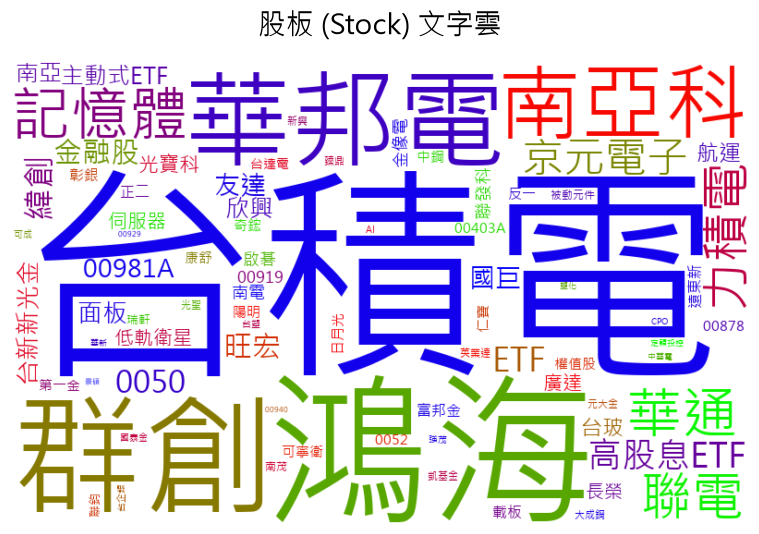

In [ ]:
# 3. 定義產生過濾後 N-gram 的函式
def get_filtered_ngrams(text, n=2):
    if not isinstance(text, str):
        return []
        
    words = text.split()
    valid_ngrams = []
    
    # 產生 N-gram
    for i in range(len(words) - n + 1):
        ngram_words = words[i:i+n]
        
        # 檢查這個 N-gram 裡面有沒有任何詞是停用詞，或長度小於2
        # 如果有，我們就不要這個 N-gram
        is_valid = True
        for w in ngram_words:
            if w in analysis_stop_words or len(w) < 2:
                is_valid = False
                break
                
        if is_valid:
            valid_ngrams.append(' '.join(ngram_words))
        
    return valid_ngrams

# 4. 分別收集房板與股板的 Bigram
unigram_stoke = []

for index, row in df.iterrows():
    board = row['artCatagory']
    text = row['segmented_content']

    unigram = get_filtered_ngrams(text, n=1)
        
    unigram_stoke.extend(unigram)

# 5. 定義畫文字雲的共用函式
def plot_wordcloud(ngram_list, title, colormap):
    counts = Counter(ngram_list)
    print(f"[{title}] 前 10 大:", counts.most_common(10))
    
    font_path = 'C:/Windows/Fonts/msjh.ttc'  # 微軟正黑體 (Mac 請改 /System/Library/Fonts/PingFang.ttc)
    
    wc = WordCloud(
        font_path=font_path, width=800, height=500,
        background_color='white', max_words=80, colormap=colormap
    )
    wc.generate_from_frequencies(counts)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20, pad=20)
    plt.axis('off')
    plt.show()

# 6. 畫圖
plot_wordcloud(unigram_stoke, "股板 (Stock) 文字雲", "brg")


### 3.6 推文資料分離

將處理完的推文整理成單筆資料。例如同一篇文同一人推文提到多檔股名，則輸出成多筆資料。

| 欄位          | 說明          |
| ----------- | ----------- |
| cmtPoster   | 推文者 |
| transDate   | 交易日   |
| cmtStatus   | 推/噓/→ |
| stock_name | 股名 |


In [ ]:
comment_raw = pd.read_csv('data/net_buy_sell_segmented_comments.csv', header=0, encoding='utf-8-sig', thousands=',')

#取出所有不重複的stock_id,stock_name組合
#unique_stocks = raw[['stock_id', 'stock_name']].drop_duplicates()

comments = comment_raw[['cmtPoster', 'transDate', 'cmtStatus', 'segmented_content']]
#移除segmented_content為空的留言
comments = comments[comments['segmented_content'].notna()]


group_cols = ["cmtPoster", "transDate", "cmtStatus"]

def unique_stocks(series):
    stocks = []

    for text in series.dropna():
        for stock in str(text).split():
            stock = stock.strip()
            if stock and stock not in stocks:
                stocks.append(stock)

    return stocks

result = (
    comments.groupby(group_cols)["segmented_content"]
      .apply(unique_stocks)
      .reset_index(name="stock_name")
      .explode("stock_name")
      .dropna(subset=["stock_name"])
      .sort_values(
          ["transDate", "cmtPoster", "cmtStatus", "stock_name"]
      )
      .reset_index(drop=True)
)

result.to_csv("./data/comment_stock_mentions.csv", index=False, encoding="utf-8-sig")


加入`entity_type`欄位，輸出為最終使用的`comment_stock_mentions_with_entity_type.csv`

In [ ]:
THEMES = {
    "AI", "CPO", "DRAM", "PCB", "太陽能", "主動式ETF", "市值型ETF", "高股息ETF", "權值股",
    "塑化", "光通訊", "伺服器","低軌衛星", "矽光子", "矽電容", "金融股", "封測", "玻纖布",
    "軍工", "面板", "航運", "航空", "記憶體", "被動元件", "散熱", "載板", "電子", "電源", "鋼鐵", "ETF"
}

def get_entity_type(name):

    if pd.isna(name):
        return None

    name = str(name).strip()

    # 投資主題
    if name in THEMES:
        return "投資主題"

    # ETF
    # 0050
    # 00878
    # 00919
    # 00679B
    # 00715L
    # 00632R
    # 009816
    if re.fullmatch(r"\d{4,6}[A-Z]?", name):
        return "ETF"

    return "個股"

df["entity_type"] = df["stock_name"].apply(get_entity_type)

df.to_csv('data/comment_stock_mentions_with_entity_type.csv', encoding='utf-8-sig', index=False)